# Face Detection & Recognition Pipeline

In [2]:
import sys
from pathlib import Path
import os

# Add project root to Python path
# Detect if we're in notebooks/ directory and adjust accordingly
current_dir = Path(os.getcwd()).resolve()
if current_dir.name == 'notebooks':
    # Running from notebooks/ directory, go up one level
    project_root = current_dir.parent
else:
    # Running from project root or elsewhere, try relative path
    project_root = Path('..').resolve() if (Path('.') / 'notebooks').exists() else current_dir

# Add to path if not already there
project_root_str = str(project_root.resolve())
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

# Import all required modules
from src.data_loader import load_wider_face, load_custom_pascal_voc
from src.dataset_wrapper import FaceDataset
from src.face_detector import HaarFaceDetector, YOLOFaceDetector, visualize_detections
from src.face_recognizer import FaceRecognizer
from src.preprocessing import resize_and_normalize, augment_image

## 1. Project Configuration


In [3]:
import cv2
import insightface


In [4]:
from dataclasses import dataclass

@dataclass
class PipelineConfig:
    project_root: Path = Path('..').resolve()
    data_dir: Path = project_root / 'data'
    raw_dir: Path = data_dir / 'raw'
    annotations_dir: Path = data_dir / 'annotations'
    reference_dir: Path = data_dir / 'reference'
    processed_dir: Path = data_dir / 'processed'
    wider_split: str = 'train'
    batch_size: int = 4
    image_size: tuple[int, int] = (512, 512)
    yolo_model: str = 'yolov8n.pt'
    yolo_epochs: int = 25
    yolo_data_cfg: Path = data_dir / 'face_yolo.yaml'

cfg = PipelineConfig()
cfg


PipelineConfig(project_root=PosixPath('/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline'), data_dir=PosixPath('/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data'), raw_dir=PosixPath('/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data/raw'), annotations_dir=PosixPath('/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data/annotations'), reference_dir=PosixPath('/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data/reference'), processed_dir=PosixPath('/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data/processed'), wider_split='train', batch_size=4, image_size=(512, 512), yolo_model='yolov8n.pt', yolo_epochs=25, yolo_data_cfg=PosixPath('/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data/face_yolo.yaml'))

## 2. Dataset Loading & Preprocessing
We reuse the TFDS pipeline from Assignment 3 for WIDER FACE and the Pascal VOC loader for custom images of the target person.


In [5]:
# Load WIDER FACE dataset
# The loader will automatically fall back to loading from extracted files if TFDS has download issues
wider_ds = load_wider_face(
    split=cfg.wider_split,
    data_dir=cfg.data_dir,
    batch_size=cfg.batch_size,
    image_size=cfg.image_size,
    download_mode='reuse_cache_if_exists',  # Tries to use existing downloads, falls back to direct loading if needed
)

# Load custom Pascal VOC dataset
custom_ds = load_custom_pascal_voc(
    images_dir=cfg.raw_dir,
    annotations_dir=cfg.annotations_dir,
    image_size=cfg.image_size,
)

wider_ds, custom_ds


/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/src/data_loader.py:207: UserWarning: Dataset not prepared yet. Will attempt to prepare using existing downloads.
  warnings.warn(
/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...: 0 url [00:00, ? url/s]
Dl Completed...:  75%|███████▌  | 3/4 [00:00<00:00, 145.97 url/s]
Extraction completed...: 0 file [00:00, ? file/s]
Dl Completed...:  75%|███████▌  | 3/4 [00:00<00:00,  3.90 url/s] 
/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/src/data_loader.py:432: UserWarning: TFDS download failed. Attempting to load directly from extracted files...
  warnings.warn(
/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/src/data_loader.py:439: UserWarning: Successfully loaded dataset from extracted files (without annotations).
Note: Bounding boxes are empty. To load with annotations, ensure annotation files are available.
  warnings.warn(


(<_PrefetchDataset element_spec={'image': TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name=None), 'bboxes': TensorSpec(shape=(None, None, 4), dtype=tf.float32, name=None), 'labels': TensorSpec(shape=(None, None), dtype=tf.int32, name=None)}>,
 <_FlatMapDataset element_spec={'image': TensorSpec(shape=(512, 512, 3), dtype=tf.float32, name=None), 'bboxes': TensorSpec(shape=(None, 4), dtype=tf.float32, name=None), 'labels': TensorSpec(shape=(None,), dtype=tf.int32, name=None), 'image_id': TensorSpec(shape=(), dtype=tf.string, name=None)}>)

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vishesh1412/celebrity-face-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/sarangsawant/.cache/kagglehub/datasets/vishesh1412/celebrity-face-image-dataset/versions/1


## 2.5. Generate YOLO Labels (if not already created)

If you don't have YOLO format label files (.txt), you can automatically generate them by detecting faces in your images.

**YOLO Label Format:**
- Each image needs a corresponding `.txt` file with the same name
- Format: `class_id center_x center_y width height` (all normalized 0-1)
- Example: `0 0.5 0.5 0.3 0.4` means a face at center with 30% width and 40% height

**Options:**
1. **Automatic detection** (recommended): Use the script below to detect faces and generate labels
2. **Manual annotation**: Use tools like LabelImg, CVAT, or Roboflow to manually annotate
3. **Use existing annotations**: Convert from Pascal VOC XML or other formats


In [7]:

# Generate YOLO labels automatically by detecting faces
# This will:
# 1. Detect faces in all images in cfg.raw_dir (including subdirectories)
# 2. Generate .txt label files in YOLO format
# 3. Organize images into train/val splits
# 4. Copy images and labels to data/raw/train/ and data/raw/val/

import subprocess
import sys
from pathlib import Path

# Run the label generation script
script_path = cfg.project_root / "generate_yolo_labels.py"

if script_path.exists():
    print("Generating YOLO labels...")
    print("This may take a while depending on the number of images.")
    
    # Run with Haar Cascade (fast, no GPU needed)
    result = subprocess.run(
        [
            sys.executable,
            str(script_path),
            "--input", str(cfg.raw_dir),
            "--output-images", str(cfg.raw_dir),
            "--output-labels", str(cfg.raw_dir),
            "--method", "haar",  # Use "yolo" if you have a face detection model
            "--train-split", "0.8",
        ],
        capture_output=True,
        text=True
    )
    
    if result.returncode == 0:
        print("✅ Labels generated successfully!")
        print(result.stdout)
    else:
        print("❌ Error generating labels:")
        print(result.stderr)
        print("\nYou can also run this from terminal:")
        print(f"  python {script_path} --input {cfg.raw_dir} --method haar")
else:
    print(f"⚠️  Script not found at {script_path}")
    print("You can manually create labels or use annotation tools like LabelImg.")


Generating YOLO labels...
This may take a while depending on the number of images.
❌ Error generating labels:

  0%|          | 4/2824 [00:00<03:34, 13.13it/s]
Traceback (most recent call last):
  File "/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/generate_yolo_labels.py", line 314, in <module>
    main()
  File "/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/generate_yolo_labels.py", line 302, in main
    process_images(
  File "/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/generate_yolo_labels.py", line 186, in process_images
    process_single_image(
  File "/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/generate_yolo_labels.py", line 236, in process_single_image
    shutil.copy2(image_path, output_image_path)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/shutil.py", line 475, in copy2
    copyfile(src, dst, follow_symlinks=follow_symlink

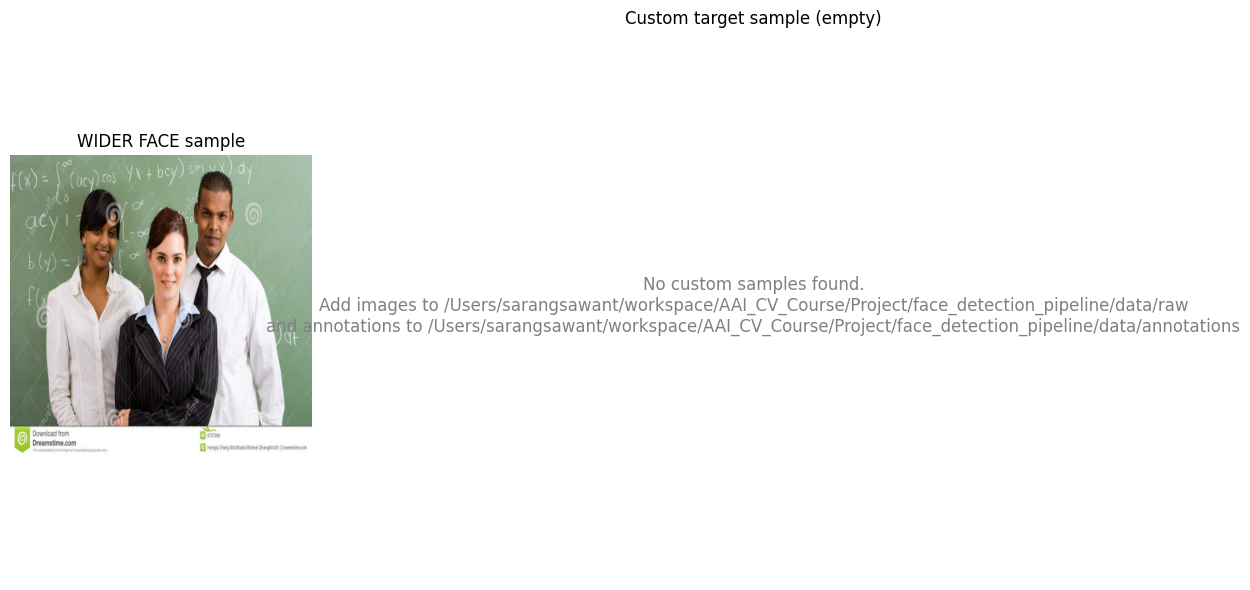

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize WIDER FACE sample
sample = next(iter(wider_ds.take(1)))
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display WIDER FACE sample
wider_image = sample['image'][0].numpy()
# Ensure image is in [0, 1] range for display
if wider_image.max() > 1.0:
    wider_image = wider_image / 255.0
axes[0].imshow(wider_image)
axes[0].set_title('WIDER FACE sample')
axes[0].axis('off')

# Check if custom dataset has samples
custom_iter = iter(custom_ds.take(1))
try:
    custom_sample = next(custom_iter)
    custom_image = custom_sample['image'].numpy()
    # Ensure image is in [0, 1] range for display
    if custom_image.max() > 1.0:
        custom_image = custom_image / 255.0
    axes[1].imshow(custom_image)
    axes[1].set_title('Custom target sample')
except StopIteration:
    # Custom dataset is empty - show placeholder message
    axes[1].text(0.5, 0.5, 
                 'No custom samples found.\n'
                 f'Add images to {cfg.raw_dir}\n'
                 f'and annotations to {cfg.annotations_dir}',
                 ha='center', va='center', 
                 fontsize=12, color='gray',
                 transform=axes[1].transAxes)
    axes[1].set_title('Custom target sample (empty)')
except Exception as e:
    # Handle other exceptions (e.g., OutOfRangeError from TensorFlow)
    if 'OutOfRange' in str(type(e).__name__) or 'End of sequence' in str(e):
        axes[1].text(0.5, 0.5, 
                     'No custom samples found.\n'
                     f'Add images to {cfg.raw_dir}\n'
                     f'and annotations to {cfg.annotations_dir}',
                     ha='center', va='center', 
                     fontsize=12, color='gray',
                     transform=axes[1].transAxes)
        axes[1].set_title('Custom target sample (empty)')
    else:
        # Re-raise if it's a different error
        raise
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 3. Detector Training (YOLOv8 fine-tuning)
Export the custom dataset to YOLO format (images + label txt) under `data/raw/train|val` before running.


In [9]:
from ultralytics import YOLO

if not cfg.yolo_data_cfg.exists():
    raise FileNotFoundError(f"Missing YOLO data config at {cfg.yolo_data_cfg}")

model = YOLO(cfg.yolo_model)
train_results = model.train(
    data=str(cfg.yolo_data_cfg),
    epochs=cfg.yolo_epochs,
    imgsz=cfg.image_size[0],
    project=str(cfg.project_root / 'results'),
    name='yolo_face_tuned',
)
train_results


New https://pypi.org/project/ultralytics/8.3.233 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.230 🚀 Python-3.12.10 torch-2.9.1 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data/face_yolo.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=F

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x16cabffb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048,    

## 4. Evaluation
Run validation on the held-out split to compute mAP and visualize predictions.


In [10]:
val_results = model.val(
    data=str(cfg.yolo_data_cfg),
    imgsz=cfg.image_size[0],
    conf=0.25,
)
val_results


Ultralytics 8.3.230 🚀 Python-3.12.10 torch-2.9.1 CPU (Apple M4)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 131.8±23.3 MB/s, size: 31.1 KB)
val: Scanning /Users/sarangsawant/workspace/AAI_CV_Course/Project/face_detection_pipeline/data/raw/val.cache... 347 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 347/347 908.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 1.2s/it 26.1s1.1ss
                   all        347        421      0.989      0.846      0.928      0.813
Speed: 0.3ms preprocess, 72.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /Users/sarangsawant/workspace/runs/detect/val2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x1781418b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048,    

## 5. Specific Person Recognition
Use the fine-tuned detector to crop faces, then match embeddings against the target identity reference set.


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/sarangsawant/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/sarangsawant/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/sarangsawant/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/sarangsawant/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/sarangsawant/.insightface/models/buffalo_l/w600k_r50.onnx recognition [

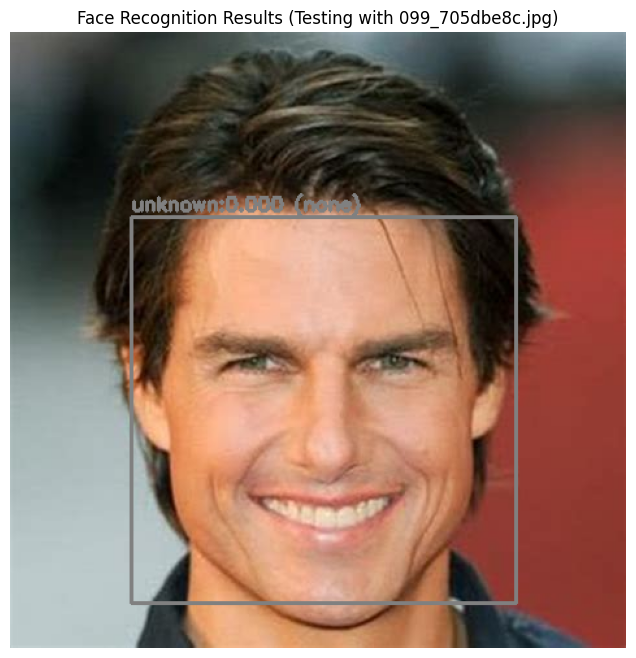


Face Deletion Example
Deleted 0 face(s) of 'Tom Cruise'


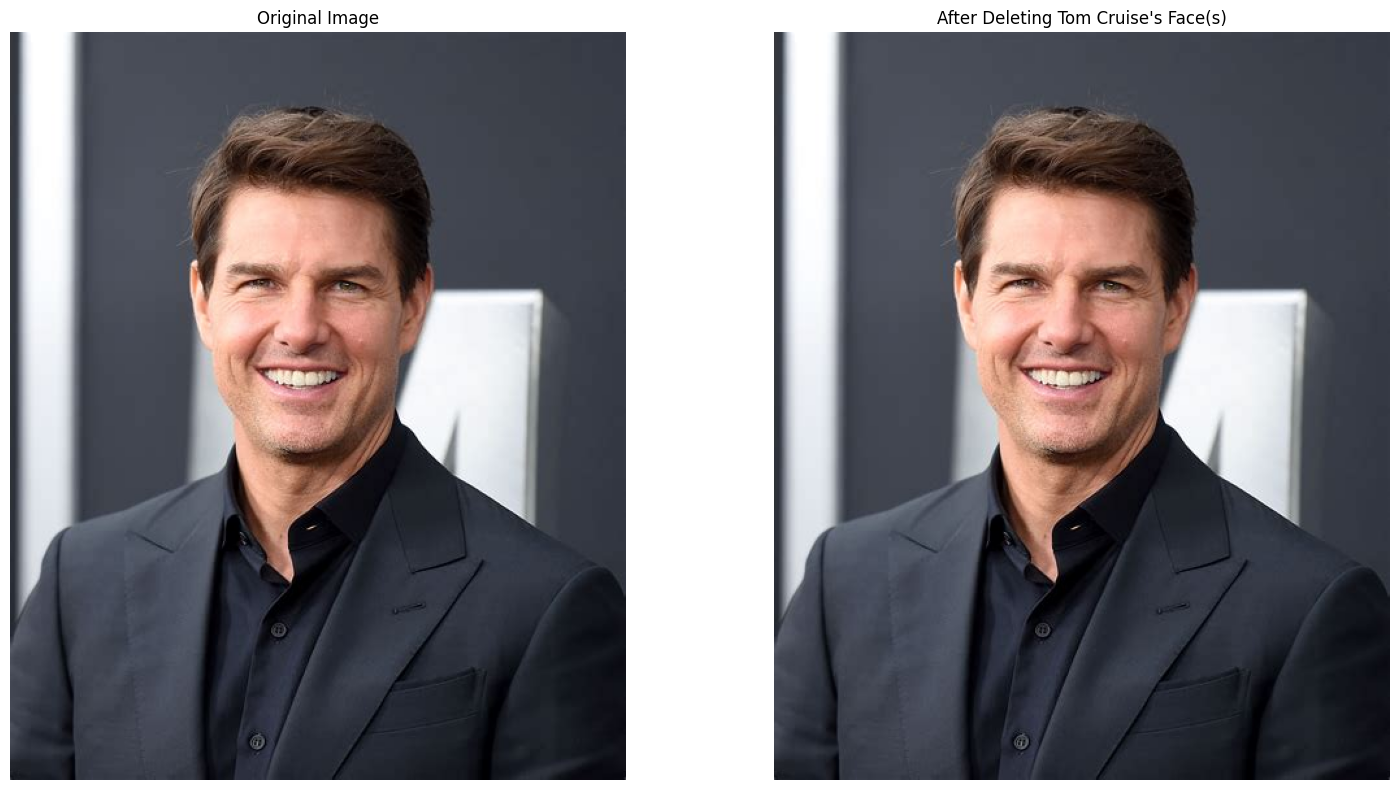

In [ ]:
import glob
import importlib
from src import face_recognizer
from src import face_detector

# Reload the module to pick up the latest changes
importlib.reload(face_recognizer)
importlib.reload(face_detector)
from src.face_recognizer import FaceRecognizer
from src.face_detector import YOLOFaceDetector, delete_specific_person_faces

# Use CPUExecutionProvider on macOS (CUDA is not available)
# Will try buffalo_l, buffalo_m, buffalo_s in order
face_recognizer = FaceRecognizer(providers=['CPUExecutionProvider'])

# Load reference images for the target person
reference_images = glob.glob(str(cfg.reference_dir / '*.jpg'))
if not reference_images:
    raise FileNotFoundError(f"Place reference images in {cfg.reference_dir}")

# Add all reference images (now supports multiple images per identity)
target_identity = 'Tom Cruise'  # Change this to match your target person
print(f"Loading reference images for '{target_identity}'...")
for ref_img in reference_images:
    face_recognizer.add_reference_image(name=target_identity, image_path=ref_img)

# Validate reference images
print(f"\n{'='*60}")
print(f"Validation results for '{target_identity}':")
print(f"{'='*60}")
validation = face_recognizer.validate_reference_images(target_identity)
print(f"  Valid: {validation['valid']}")
print(f"  Number of references: {validation.get('num_references', 0)}")
if 'avg_distance' in validation:
    print(f"  Average embedding distance: {validation['avg_distance']:.3f}")
    print(f"  Max distance: {validation['max_distance']:.3f}")
    print(f"  Std deviation: {validation['std_distance']:.3f}")
    
    # Provide guidance based on variance
    avg_dist = validation['avg_distance']
    if avg_dist > 0.5:
        print(f"\n  ⚠️  CRITICAL WARNING: Very high variance detected!")
        print(f"  This suggests reference images may contain different people.")
        print(f"  Recommendation: Review and filter reference images to ensure they're all of '{target_identity}'")
    elif avg_dist > 0.4:
        print(f"\n  ⚠️  WARNING: Moderate variance detected.")
        print(f"  Some reference images may be inconsistent.")
    
if not validation['valid']:
    print(f"\n Validation Failed: {validation.get('reason', 'Unknown issue')}")
    if 'suggestion' in validation:
        print(f"  💡 Suggestion: {validation['suggestion']}")
    if 'recommendation' in validation:
        print(f"  📋 Recommendation: {validation['recommendation']}")
elif validation.get('warning'):
    print(f"\n  ⚠️  Warning: {validation.get('warning', '')}")
    if 'suggestion' in validation:
        print(f"  💡 Suggestion: {validation['suggestion']}")

# Suggest threshold adjustment if variance is high
if 'avg_distance' in validation:
    avg_dist = validation['avg_distance']
    if avg_dist > 0.4:
        suggested_threshold = min(0.6, avg_dist * 0.7)  # Suggest threshold based on variance
        print(f"\n  💡 Threshold Suggestion: Consider using threshold={suggested_threshold:.2f} instead of 0.25")
        print(f"     (Current avg distance: {avg_dist:.3f} is higher than typical 0.2-0.3)")

# Load YOLO model for face detection
inference_model = YOLO(cfg.project_root / 'results/yolo_face_tuned6/weights/best.pt')
yolo_detector = YOLOFaceDetector(model_name=str(cfg.project_root / 'results/yolo_face_tuned6/weights/best.pt'))

# Test image - try with different person to verify it doesn't match
# data/raw/Johnny Depp/002_331d0423.jpg # Test with different person
# data/raw/Tom Cruise/001_08212dcd.jpg
# data/raw/Tom Cruise/099_705dbe8c.jpg
input_image_path = cfg.raw_dir / 'Tom Cruise/099_705dbe8c.jpg'  
if not input_image_path.exists():
    raise FileNotFoundError(f"Provide an inference image at {input_image_path}")

print(f"\n{'='*60}")
print(f"Testing face recognition on: {input_image_path.name}")
print(f"{'='*60}")

image_bgr = cv2.imread(str(input_image_path))
yolo_detections = inference_model.predict(image_bgr, conf=0.25, verbose=False)
visualized = image_bgr.copy()

# Process each detected face
for result in yolo_detections:
    if result.boxes is None:
        continue
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        crop = image_bgr[y1:y2, x1:x2]
        
        try:
            # Try to match with diagnostic mode to see best score even if above threshold
            matches = face_recognizer.match(crop, threshold=0.25, confidence_levels=True, return_all_scores=True)
            
            label = 'unknown'
            score = 0.0
            confidence = 'none'
            above_threshold = False
            
            if matches:
                match = matches[0]
                label = match['name']
                score = match['score']
                confidence = match.get('confidence', 'unknown')
                above_threshold = match.get('above_threshold', False)
                
                if above_threshold:
                    print(f"  Face detected: {label} (score: {score:.3f}, confidence: {confidence}, ABOVE THRESHOLD)")
                else:
                    print(f"  Face detected: {label} (score: {score:.3f}, confidence: {confidence})")
            else:
                # No match found - try to get diagnostic info
                try:
                    # Get best score manually for diagnostics
                    faces = face_recognizer.app.get(crop)
                    if faces:
                        embedding = faces[0].normed_embedding
                        best_score = float('inf')
                        best_name = None
                        for profile in face_recognizer.identities.values():
                            if profile.embeddings:
                                score = profile.get_best_match(embedding)
                                if score < best_score:
                                    best_score = score
                                    best_name = profile.name
                        
                        if best_name:
                            print(f"  Face detected: unknown (best match: {best_name} with score {best_score:.3f}, threshold: 0.25)")
                        else:
                            print(f"  Face detected: unknown (no identities registered)")
                    else:
                        print(f"  Face detected: unknown (no face detected in crop)")
                except Exception as e:
                    print(f"  Face detected: unknown (error getting diagnostics: {str(e)})")
        
        except Exception as e:
            print(f"  ERROR in face recognition: {str(e)}")
            label = 'error'
            score = 0.0
            confidence = 'error'
        
        # Color code based on match
        if label == target_identity:
            color = (0, 255, 0)  # Green for correct match
        elif label != 'unknown':
            color = (0, 0, 255)  # Red for wrong match
        else:
            color = (128, 128, 128)  # Gray for unknown
        
        cv2.rectangle(visualized, (x1, y1), (x2, y2), color, 2)
        text = f"{label}:{score:.3f} ({confidence})"
        cv2.putText(visualized, text, (x1, max(0, y1 - 5)), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(visualized, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'Face Recognition Results (Testing with {input_image_path.name})')
plt.show()

# # Example: Delete target person's face from image
# print(f"\n{'='*60}")
# print("Face Deletion Example")
# print(f"{'='*60}")

# # Create a test image with the target person
# test_image_path = cfg.raw_dir / 'Tom Cruise/001_08212dcd.jpg'
# if test_image_path.exists():
#     test_image = cv2.imread(str(test_image_path))
    
#     # Delete only the target person's faces
#     deleted_image, deleted_detections = delete_specific_person_faces(
#         test_image,
#         face_recognizer,
#         yolo_detector,
#         target_identity=target_identity,
#         deletion_method="blur",  # or "pixelate", "black", "inpaint"
#         recognition_threshold=0.25,
#         blur_strength=51
#     )
    
#     print(f"Deleted {len(deleted_detections)} face(s) of '{target_identity}'")
    
#     # Visualize before and after
#     fig, axes = plt.subplots(1, 2, figsize=(16, 8))
#     axes[0].imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
#     axes[0].set_title('Original Image')
#     axes[0].axis('off')
    
#     axes[1].imshow(cv2.cvtColor(deleted_image, cv2.COLOR_BGR2RGB))
#     axes[1].set_title(f'After Deleting {target_identity}\'s Face(s)')
#     axes[1].axis('off')
    
#     plt.tight_layout()
#     plt.show()
# else:
#     print(f"Test image not found: {test_image_path}")
